[INFO] #pairs contributing to Fig. 1D–E aggregates (AFM-based): All=320, Viral-Human=204, Bacteria-Human=116


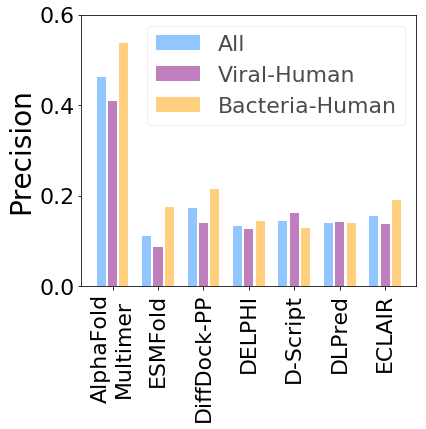

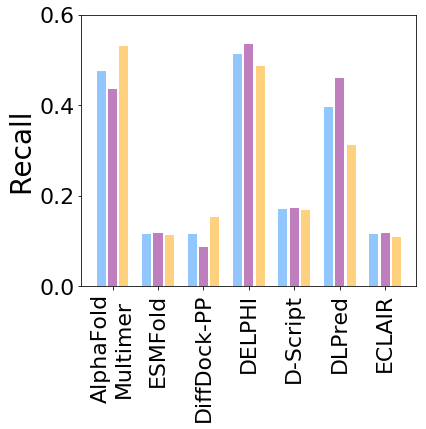

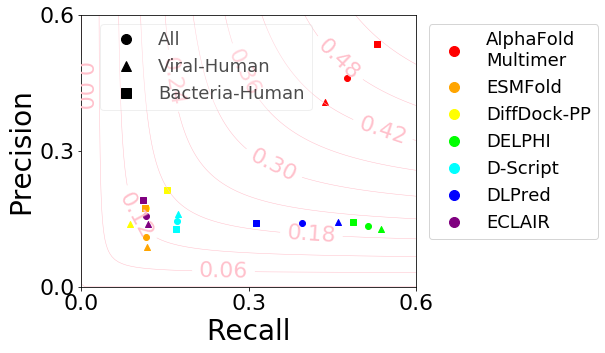

In [14]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

plt.style.use("seaborn-pastel")

# =========================
# Config (keep semantics identical)
# =========================
WKDIR = "Fig1D-E/"
OUTPUT_DIR = "Fig1D-E/"

# Score and pLDDT thresholds actually used in this script / manuscript
SCORE_THR = (0.0, 1.0)
PLDDT_THR = (50.0, 100.0)  # AFM interface pLDDT threshold used in Fig. 1D–E

TIME_MODE = 0              # 0: all benchmark data; 1: only Date_after_train == True
PT_PAT = "allProts"        # currently use all proteins, not human-only / non-human-only
PAT = "aggregation_"       # matches original filename pattern
EPS = 1e-5                 # tiny epsilon for safety in precision/recall

# Method keys (internal) and display labels (what shows on the x-axis)
METHOD_KEYS = ["AFM", "ESMF", "DDPP", "DEL", "DSC", "DLP", "ECL"]
METHOD_LABELS = [
    "AlphaFold\nMultimer",
    "ESMFold",
    "DiffDock-PP",
    "DELPHI",
    "D-Script",
    "DLPred",
    "ECLAIR",
]


# =========================
# Small helpers
# =========================
def convert_ires_string_to_list(ires_string: str):
    """
    Convert an interface residue string like '[10,12-15,20]' -> [10, 12, 13, 14, 15, 20].
    Empty '[]' or '' -> [].
    """
    s = ires_string.replace("[", "").replace("]", "")
    if s.strip() == "":
        return []
    segments = s.split(",")
    nested = [
        list(range(int(seg.split("-")[0]), int(seg.split("-")[1]) + 1)) if "-" in seg else [int(seg)]
        for seg in segments
    ]
    return [pos for sub in nested for pos in sub]


def calc_res(IresA, IresB, pIresA, pIresB, sel_pt: int = 0):
    """
    Per-pair precision/recall, exactly as in original code.
    sel_pt=0: both chains; 1: chain A only; 2: chain B only.
    """
    i1 = len(set(pIresA) & set(IresA))
    i2 = len(set(pIresB) & set(IresB))

    if sel_pt == 0:
        pre = round((i1 + i2) / (len(pIresA) + len(pIresB) + EPS), 3)
        rec = round((i1 + i2) / (len(IresA) + len(IresB) + EPS), 3)
    elif sel_pt == 1:
        pre = round(i1 / (len(pIresA) + EPS), 3)
        rec = round(i1 / (len(IresA) + EPS), 3)
    elif sel_pt == 2:
        pre = round(i2 / (len(pIresB) + EPS), 3)
        rec = round(i2 / (len(IresB) + EPS), 3)
    else:
        raise ValueError("sel_pt must be 0, 1, or 2.")
    return pre, rec


def calc_res_set(IresA_all, IresB_all, pIresA_all, pIresB_all, sel_pt: int = 0):
    """
    Global (micro-averaged) precision/recall over all residues, exactly as in original code.
    """
    i1 = len(set(pIresA_all) & set(IresA_all))
    i2 = len(set(pIresB_all) & set(IresB_all))

    if sel_pt == 0:
        pre = round((i1 + i2) / (len(pIresA_all) + len(pIresB_all) + EPS), 3)
        rec = round((i1 + i2) / (len(IresA_all) + len(IresB_all) + EPS), 3)
    elif sel_pt == 1:
        pre = round(i1 / (len(pIresA_all) + EPS), 3)
        rec = round(i1 / (len(IresA_all) + EPS), 3)
    elif sel_pt == 2:
        pre = round(i2 / (len(pIresB_all) + EPS), 3)
        rec = round(i2 / (len(IresB_all) + EPS), 3)
    else:
        raise ValueError("sel_pt must be 0, 1, or 2.")
    return pre, rec


# =========================
# Data loading
# =========================
def load_prediction_tables():
    """
    Load benchmark table and per-method prediction tables.
    Paths and selected columns follow the original script exactly.
    """
    v2h_lst = pd.read_csv(
        f"{WKDIR}interface_all_interspecies_AFM_ESM_all_score_pdockq_benchmark_with_info.txt",
        sep="\t",
    )

    v2h_ESM = (
        pd.read_csv(
            f"{WKDIR}interface_all_interspecies_pre_rec_ESM_pdockq.txt",
            sep="\t",
        )[["#Pair_id", "Precision", "Recall", "Ires_c1_pred", "Ires_c2_pred"]]
        .rename(
            columns={
                "#Pair_id": "Pair",
                "Ires_c1_pred": "pIresA",
                "Ires_c2_pred": "pIresB",
            }
        )
    )

    v2h_DDPP = (
        pd.read_csv(
            f"{WKDIR}interface_all_interspecies_pre_rec_DDPP.txt",
            sep="\t",
        )[["#Pair_id", "Precision", "Recall", "Ires_c1_pred", "Ires_c2_pred"]]
        .rename(
            columns={
                "#Pair_id": "Pair",
                "Ires_c1_pred": "pIresA",
                "Ires_c2_pred": "pIresB",
            }
        )
    )

    v2h_ECL = (
        pd.read_csv(
            f"{WKDIR}interface_all_interspecies_pre_rec_ECLAIR.txt",
            sep="\t",
        )[["#Pair_id", "Precision", "Recall", "Ires_c1_pred", "Ires_c2_pred"]]
        .rename(
            columns={
                "#Pair_id": "Pair",
                "Ires_c1_pred": "pIresA",
                "Ires_c2_pred": "pIresB",
            }
        )
    )

    v2h_DLP = pd.read_csv(
        f"{WKDIR}DLPred_all_results_formatted_pre_rec.txt",
        sep="\t",
        header=None,
        names=["Pair", "Precision", "Recall", "pIresA", "pIresB"],
    )
    v2h_DEL = pd.read_csv(
        f"{WKDIR}DELPHI_all_results_formatted_pre_rec.txt",
        sep="\t",
        header=None,
        names=["Pair", "Precision", "Recall", "pIresA", "pIresB"],
    )
    v2h_DSC = pd.read_csv(
        f"{WKDIR}DScript_all_results_formatted_pre_rec.txt",
        sep="\t",
        header=None,
        names=["Pair", "Precision", "Recall", "pIresA", "pIresB"],
    )

    return {
        "benchmark": v2h_lst,
        "ESM": v2h_ESM,
        "DDPP": v2h_DDPP,
        "ECL": v2h_ECL,
        "DLP": v2h_DLP,
        "DEL": v2h_DEL,
        "DSC": v2h_DSC,
    }


# =========================
# Subset selection by organism mode
# =========================
def select_pairs(v2h_lst: pd.DataFrame, org_mode: int):
    """
    org_mode:
      0 -> all organisms
      1 -> viral-human pairs
      2 -> bacterial-human (non-viral) pairs
    TIME_MODE controls whether we restrict to Date_after_train.
    """
    score_min, score_max = SCORE_THR
    base_mask = (v2h_lst["score"] >= score_min) & (v2h_lst["score"] <= score_max)

    if TIME_MODE == 1:
        base_mask &= v2h_lst["Date_after_train"]

    if org_mode == 0:
        mask = base_mask
    elif org_mode == 1:
        mask = base_mask & (
            (v2h_lst["DomainA"] == "Viruses") | (v2h_lst["DomainB"] == "Viruses")
        )
    elif org_mode == 2:
        mask = base_mask & (
            (v2h_lst["DomainA"] != "Viruses") & (v2h_lst["DomainB"] != "Viruses")
        )
    else:
        raise ValueError("org_mode must be 0 (all), 1 (viral), or 2 (bacterial).")

    return v2h_lst.loc[mask]


# =========================
# Core computation for one subset (all / viral / bacterial)
# =========================
def compute_metrics_for_subset(v2h_subset: pd.DataFrame, tables: dict, sel_pt: int = 0):
    """
    Compute global (micro-averaged) precision/recall and per-pair precision/recall
    for one organism subset, using the exact logic of the original script.

    My view: AFM interface residues are defined structurally (dSASA >= 1, rSASA >= 15,
    pLDDT within PLDDT_THR), and all other methods are compared at the residue level.
    """
    v2h_ESM = tables["ESM"]
    v2h_DDPP = tables["DDPP"]
    v2h_ECL = tables["ECL"]
    v2h_DLP = tables["DLP"]
    v2h_DEL = tables["DEL"]
    v2h_DSC = tables["DSC"]

    # Global lists (across all pairs) for micro-averaging
    IresA_all, IresB_all = [], []
    AFM_pIresA_all, AFM_pIresB_all = [], []
    ESM_pIresA_all, ESM_pIresB_all = [], []
    DDPP_pIresA_all, DDPP_pIresB_all = [], []
    ECL_pIresA_all, ECL_pIresB_all = [], []
    DEL_pIresA_all, DEL_pIresB_all = [], []
    DSC_pIresA_all, DSC_pIresB_all = [], []
    DLP_pIresA_all, DLP_pIresB_all = [], []

    # Per-pair precision/recall (hidden points before aggregation)
    AFM_pre_lst, AFM_rec_lst = [], []
    ESM_pre_lst, ESM_rec_lst = [], []
    DDPP_pre_lst, DDPP_rec_lst = [], []
    DEL_pre_lst, DEL_rec_lst = [], []
    DSC_pre_lst, DSC_rec_lst = [], []
    DLP_pre_lst, DLP_rec_lst = [], []
    ECL_pre_lst, ECL_rec_lst = [], []

    plddt_thr_min, plddt_thr_max = PLDDT_THR

    for (
        UniProtA,
        UniProtB,
        TaxIDA,
        TaxIDB,
        UniProtIresA,
        UniProtIresB,
        ProtA_rSASA,
        ProtB_rSASA,
        ProtA_dSASA,
        ProtB_dSASA,
        ProtA_res_range,
        ProtB_res_range,
        ProtA_ires_plddt,
        ProtB_ires_plddt,
    ) in v2h_subset[
        [
            "UniProtA",
            "UniProtB",
            "TaxIDA",
            "TaxIDB",
            "UniProtIresA",
            "UniProtIresB",
            "ProtA_rSASA",
            "ProtB_rSASA",
            "ProtA_dSASA",
            "ProtB_dSASA",
            "ProtA_res_range",
            "ProtB_res_range",
            "ProtA_ires_plddt",
            "ProtB_ires_plddt",
        ]
    ].values:
        pair_id = f"{UniProtA}_{UniProtB}"

        # Require that all methods have an entry for this pair (original logic)
        counts = [
            (tables["DLP"].Pair == pair_id).sum(),
            (tables["DSC"].Pair == pair_id).sum(),
            (tables["DEL"].Pair == pair_id).sum(),
            (tables["ESM"].Pair == pair_id).sum(),
            (tables["DDPP"].Pair == pair_id).sum(),
        ]
        if any(c == 0 for c in counts):
            continue

        # Currently use allProts; human-only vs non-human variants are commented in the original code.
        # If you ever switch to chain-specific metrics, update sel_pt here.
        # sel_pt = 0
        # pt_pat is handled globally as PT_PAT; no change in filenames.

        # Ground-truth interface residues per chain (Uniprot indexing)
        IresA = convert_ires_string_to_list(UniProtIresA)
        IresB = convert_ires_string_to_list(UniProtIresB)

        # === AFM interface definition (structural) ===
        res_rangeA = np.array(
            [int(ele) for ele in ProtA_res_range.replace("\n", "")[1:-1].split(",")]
        )
        res_rangeB = np.array(
            [int(ele) for ele in ProtB_res_range.replace("\n", "")[1:-1].split(",")]
        )
        dSASAA = np.array([float(ele) for ele in ProtA_dSASA.split(",")])
        dSASAB = np.array([float(ele) for ele in ProtB_dSASA.split(",")])
        rSASAA = np.array([float(ele) for ele in ProtA_rSASA.split(",")])
        rSASAB = np.array([float(ele) for ele in ProtB_rSASA.split(",")])
        ires_plddtA = np.array(
            [float(ele) for ele in ProtA_ires_plddt.replace("\n", "").split(",")]
        )
        ires_plddtB = np.array(
            [float(ele) for ele in ProtB_ires_plddt.replace("\n", "").split(",")]
        )

        pIresA = res_rangeA[
            (dSASAA >= 1.0)
            & (rSASAA >= 15.0)
            & (ires_plddtA > plddt_thr_min)
            & (ires_plddtA <= plddt_thr_max)
        ]
        pIresB = res_rangeB[
            (dSASAB >= 1.0)
            & (rSASAB >= 15.0)
            & (ires_plddtB > plddt_thr_min)
            & (ires_plddtB <= plddt_thr_max)
        ]
        if len(pIresA) * len(pIresB) == 0:
            # From my view: if AFM doesn't produce interface on either chain under this structural
            # threshold, the pair is excluded from all methods for this summary.
            continue

        AFM_pIresA = [
            f"{UniProtA}_{UniProtB}_{UniProtA}_{res}" for res in pIresA
        ]
        AFM_pIresB = [
            f"{UniProtA}_{UniProtB}_{UniProtB}_{res}" for res in pIresB
        ]

        # === ESMFold parse ===
        ESM_res = v2h_ESM[v2h_ESM.Pair == pair_id].iloc[0, :]
        if isinstance(ESM_res.pIresA, float) or ESM_res.pIresA == "[]":
            ESM_pIresA = []
        else:
            arr = np.array([int(ele) for ele in ESM_res.pIresA[1:-1].split(",")])
            ESM_pIresA = [
                f"{UniProtA}_{UniProtB}_{UniProtA}_{res}" for res in arr
            ]

        if isinstance(ESM_res.pIresB, float) or ESM_res.pIresB == "[]":
            ESM_pIresB = []
        else:
            arr = np.array([int(ele) for ele in ESM_res.pIresB[1:-1].split(",")])
            ESM_pIresB = [
                f"{UniProtA}_{UniProtB}_{UniProtB}_{res}" for res in arr
            ]

        # === DiffDock-PP parse ===
        DDPP_res = v2h_DDPP[v2h_DDPP.Pair == pair_id].iloc[0, :]
        if isinstance(DDPP_res.pIresA, float) or DDPP_res.pIresA == "[]":
            DDPP_pIresA = []
        else:
            arr = np.array(
                [
                    int(ele)
                    for ele in DDPP_res.pIresA[1:-1].split(",")
                    if ele.isnumeric()
                ]
            )
            DDPP_pIresA = [
                f"{UniProtA}_{UniProtB}_{UniProtA}_{res}" for res in arr
            ]

        if isinstance(DDPP_res.pIresB, float) or DDPP_res.pIresB == "[]":
            DDPP_pIresB = []
        else:
            arr = np.array(
                [
                    int(ele)
                    for ele in DDPP_res.pIresB[1:-1].split(",")
                    if ele.isnumeric()
                ]
            )
            DDPP_pIresB = [
                f"{UniProtA}_{UniProtB}_{UniProtB}_{res}" for res in arr
            ]

        # === DLPred parse ===
        DLP_res = v2h_DLP[v2h_DLP.Pair == pair_id].iloc[0, :]
        if isinstance(DLP_res.pIresA, float):
            DLP_pIresA = []
        else:
            arr = np.array([int(ele) for ele in DLP_res.pIresA.split(",")])
            DLP_pIresA = [
                f"{UniProtA}_{UniProtB}_{UniProtA}_{res}" for res in arr
            ]

        if isinstance(DLP_res.pIresB, float):
            DLP_pIresB = []
        else:
            arr = np.array([int(ele) for ele in DLP_res.pIresB.split(",")])
            DLP_pIresB = [
                f"{UniProtA}_{UniProtB}_{UniProtB}_{res}" for res in arr
            ]

        # === DELPHI parse ===
        DEL_res = v2h_DEL[v2h_DEL.Pair == pair_id].iloc[0, :]
        if isinstance(DEL_res.pIresA, float):
            DEL_pIresA = []
        else:
            arr = np.array([int(ele) for ele in DEL_res.pIresA.split(",")])
            DEL_pIresA = [
                f"{UniProtA}_{UniProtB}_{UniProtA}_{res}" for res in arr
            ]

        if isinstance(DEL_res.pIresB, float):
            DEL_pIresB = []
        else:
            arr = np.array([int(ele) for ele in DEL_res.pIresB.split(",")])
            DEL_pIresB = [
                f"{UniProtA}_{UniProtB}_{UniProtB}_{res}" for res in arr
            ]

        # === D-Script parse ===
        DSC_res = v2h_DSC[v2h_DSC.Pair == pair_id].iloc[0, :]
        if isinstance(DSC_res.pIresA, float):
            DSC_pIresA = []
        else:
            arr = np.array([int(ele) for ele in DSC_res.pIresA.split(",")])
            DSC_pIresA = [
                f"{UniProtA}_{UniProtB}_{UniProtA}_{res}" for res in arr
            ]

        if isinstance(DSC_res.pIresB, float):
            DSC_pIresB = []
        else:
            arr = np.array([int(ele) for ele in DSC_res.pIresB.split(",")])
            DSC_pIresB = [
                f"{UniProtA}_{UniProtB}_{UniProtB}_{res}" for res in arr
            ]

        # === ECLAIR 0.4 parse ===
        ECL_res = v2h_ECL[v2h_ECL.Pair == pair_id].iloc[0, :]
        if ECL_res.pIresA == "[]":
            ECL_pIresA = []
        else:
            arr = np.array([int(ele) for ele in ECL_res.pIresA[1:-1].split(",")])
            ECL_pIresA = [
                f"{UniProtA}_{UniProtB}_{UniProtA}_{res}" for res in arr
            ]

        if ECL_res.pIresB == "[]":
            ECL_pIresB = []
        else:
            arr = np.array([int(ele) for ele in ECL_res.pIresB[1:-1].split(",")])
            ECL_pIresB = [
                f"{UniProtA}_{UniProtB}_{UniProtB}_{res}" for res in arr
            ]

        # String-encoded truth for compatibility with predicted keys
        IresA_str = [
            f"{UniProtA}_{UniProtB}_{UniProtA}_{res}" for res in IresA
        ]
        IresB_str = [
            f"{UniProtA}_{UniProtB}_{UniProtB}_{res}" for res in IresB
        ]

        # Accumulate for global micro-average (same behavior as original mode<3 branch)
        IresA_all += IresA_str
        IresB_all += IresB_str
        AFM_pIresA_all += AFM_pIresA
        AFM_pIresB_all += AFM_pIresB
        ESM_pIresA_all += ESM_pIresA
        ESM_pIresB_all += ESM_pIresB
        DDPP_pIresA_all += DDPP_pIresA
        DDPP_pIresB_all += DDPP_pIresB
        DLP_pIresA_all += DLP_pIresA
        DLP_pIresB_all += DLP_pIresB
        DSC_pIresA_all += DSC_pIresA
        DSC_pIresB_all += DSC_pIresB
        DEL_pIresA_all += DEL_pIresA
        DEL_pIresB_all += DEL_pIresB
        ECL_pIresA_all += ECL_pIresA
        ECL_pIresB_all += ECL_pIresB

        # Per-pair precision / recall (used for “hidden” statistics)
        pre, rec = calc_res(IresA_str, IresB_str, AFM_pIresA, AFM_pIresB, sel_pt)
        AFM_pre_lst.append(pre)
        AFM_rec_lst.append(rec)

        pre, rec = calc_res(IresA_str, IresB_str, ESM_pIresA, ESM_pIresB, sel_pt)
        ESM_pre_lst.append(pre)
        ESM_rec_lst.append(rec)

        pre, rec = calc_res(IresA_str, IresB_str, DDPP_pIresA, DDPP_pIresB, sel_pt)
        DDPP_pre_lst.append(pre)
        DDPP_rec_lst.append(rec)

        pre, rec = calc_res(IresA_str, IresB_str, DLP_pIresA, DLP_pIresB, sel_pt)
        DLP_pre_lst.append(pre)
        DLP_rec_lst.append(rec)

        pre, rec = calc_res(IresA_str, IresB_str, DSC_pIresA, DSC_pIresB, sel_pt)
        DSC_pre_lst.append(pre)
        DSC_rec_lst.append(rec)

        pre, rec = calc_res(IresA_str, IresB_str, DEL_pIresA, DEL_pIresB, sel_pt)
        DEL_pre_lst.append(pre)
        DEL_rec_lst.append(rec)

        pre, rec = calc_res(IresA_str, IresB_str, ECL_pIresA, ECL_pIresB, sel_pt)
        ECL_pre_lst.append(pre)
        ECL_rec_lst.append(rec)

    # Global micro-averaged precision/recall per method (order matters for plotting)
    pre_dic = {}
    rec_dic = {}

    pre_dic["AFM"], rec_dic["AFM"] = calc_res_set(
        IresA_all, IresB_all, AFM_pIresA_all, AFM_pIresB_all, sel_pt
    )
    pre_dic["ESMF"], rec_dic["ESMF"] = calc_res_set(
        IresA_all, IresB_all, ESM_pIresA_all, ESM_pIresB_all, sel_pt
    )
    pre_dic["DDPP"], rec_dic["DDPP"] = calc_res_set(
        IresA_all, IresB_all, DDPP_pIresA_all, DDPP_pIresB_all, sel_pt
    )
    pre_dic["DEL"], rec_dic["DEL"] = calc_res_set(
        IresA_all, IresB_all, DEL_pIresA_all, DEL_pIresB_all, sel_pt
    )
    pre_dic["DSC"], rec_dic["DSC"] = calc_res_set(
        IresA_all, IresB_all, DSC_pIresA_all, DSC_pIresB_all, sel_pt
    )
    pre_dic["DLP"], rec_dic["DLP"] = calc_res_set(
        IresA_all, IresB_all, DLP_pIresA_all, DLP_pIresB_all, sel_pt
    )
    pre_dic["ECL"], rec_dic["ECL"] = calc_res_set(
        IresA_all, IresB_all, ECL_pIresA_all, ECL_pIresB_all, sel_pt
    )

    # Per-pair precision/recall distributions (for hidden stats / future boxplots)
    pre_ind_dic = {
        "AFM": AFM_pre_lst,
        "ESMF": ESM_pre_lst,
        "DDPP": DDPP_pre_lst,
        "DEL": DEL_pre_lst,
        "DSC": DSC_pre_lst,
        "DLP": DLP_pre_lst,
        "ECL": ECL_pre_lst,
    }
    rec_ind_dic = {
        "AFM": AFM_rec_lst,
        "ESMF": ESM_rec_lst,
        "DDPP": DDPP_rec_lst,
        "DEL": DEL_rec_lst,
        "DSC": DSC_rec_lst,
        "DLP": DLP_rec_lst,
        "ECL": ECL_rec_lst,
    }

    return pre_dic, rec_dic, pre_ind_dic, rec_ind_dic


# =========================
# Plotting (Fig. 1D and 1E)
# =========================
def main():
    tables = load_prediction_tables()
    v2h_lst = tables["benchmark"]

    # Collect results for All, Viral-Human, Bacteria-Human
    pre_dic_all = rec_dic_all = pre_ind_dic_all = rec_ind_dic_all = None
    pre_dic_vir = rec_dic_vir = pre_ind_dic_vir = rec_ind_dic_vir = None
    pre_dic_bac = rec_dic_bac = pre_ind_dic_bac = rec_ind_dic_bac = None

    for org_mode in [0, 1, 2]:
        v2h_subset = select_pairs(v2h_lst, org_mode)
        pre_dic, rec_dic, pre_ind_dic, rec_ind_dic = compute_metrics_for_subset(
            v2h_subset, tables, sel_pt=0
        )

        if org_mode == 0:
            pre_dic_all, rec_dic_all = pre_dic, rec_dic
            pre_ind_dic_all, rec_ind_dic_all = pre_ind_dic, rec_ind_dic
        elif org_mode == 1:
            pre_dic_vir, rec_dic_vir = pre_dic, rec_dic
            pre_ind_dic_vir, rec_ind_dic_vir = pre_ind_dic, rec_ind_dic
        elif org_mode == 2:
            pre_dic_bac, rec_dic_bac = pre_dic, rec_dic
            pre_ind_dic_bac, rec_ind_dic_bac = pre_ind_dic, rec_ind_dic

    # =========================
    # Hidden statistics: # of per-pair points behind each group
    # =========================
    # From my view, these are the number of pairs contributing to each category
    # (based on AFM-filtered pairs; all methods see the same set of pairs).
    n_all = len(pre_ind_dic_all["AFM"])
    n_vir = len(pre_ind_dic_vir["AFM"])
    n_bac = len(pre_ind_dic_bac["AFM"])
    print(
        f"[INFO] #pairs contributing to Fig. 1D–E aggregates (AFM-based): "
        f"All={n_all}, Viral-Human={n_vir}, Bacteria-Human={n_bac}"
    )

    # =========================
    # Figure 1D – Precision and Recall bar plots
    # =========================
    font1 = 22
    font2 = 28
    plt.rcParams.update({"font.size": font1})

    labels = METHOD_LABELS
    # keep order consistent with METHOD_KEYS
    data_p_all = [pre_dic_all[k] for k in METHOD_KEYS]
    data_p_vir = [pre_dic_vir[k] for k in METHOD_KEYS]
    data_p_bac = [pre_dic_bac[k] for k in METHOD_KEYS]

    # --- Precision ---
    fig, ax = plt.subplots(figsize=(6, 5))
    x = np.arange(len(labels)) * 4 + 1
    ax.bar(x, data_p_all, label="All")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)

    x = np.arange(len(labels)) * 4 + 2
    ax.bar(x, data_p_vir, label="Viral-Human", color="purple", alpha=0.5)
    x = np.arange(len(labels)) * 4 + 3
    ax.bar(x, data_p_bac, label="Bacteria-Human", color="orange", alpha=0.5)

    leg = ax.legend(loc="upper right", fontsize=font1, framealpha=0.3)
    for text in leg.get_texts():
        text.set_alpha(0.7)

    plt.xticks(np.arange(len(labels)) * 4 + 2, labels, rotation=90)
    plt.ylabel("Precision", fontsize=font2)
    plt.gca().yaxis.grid(False)  # as in Feb 23, 2025 change
    plt.ylim([0, 0.6])
    plt.yticks([0, 0.2, 0.4, 0.6])

    score_thr_min, score_thr_max = SCORE_THR
    plddt_thr_min, plddt_thr_max = int(PLDDT_THR[0]), int(PLDDT_THR[1])

    fig.savefig(
        f"{OUTPUT_DIR}/Fig1D-left.svg",
        format="svg",
        bbox_inches="tight",
    )

    # --- Recall ---
    data_r_all = [rec_dic_all[k] for k in METHOD_KEYS]
    data_r_vir = [rec_dic_vir[k] for k in METHOD_KEYS]
    data_r_bac = [rec_dic_bac[k] for k in METHOD_KEYS]

    fig, ax = plt.subplots(figsize=(6, 5))
    x = np.arange(len(labels)) * 4 + 1
    ax.bar(x, data_r_all, label="All")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)

    x = np.arange(len(labels)) * 4 + 2
    ax.bar(x, data_r_vir, label="Viral-Human", color="purple", alpha=0.5)
    x = np.arange(len(labels)) * 4 + 3
    ax.bar(x, data_r_bac, label="Bacteria-Human", color="orange", alpha=0.5)

    plt.xticks(np.arange(len(labels)) * 4 + 2, labels, rotation=90)
    plt.ylabel("Recall", fontsize=font2)
    plt.gca().yaxis.grid(False)
    plt.ylim([0, 0.6])
    plt.yticks([0, 0.2, 0.4, 0.6])

    plt.show()  # keep behavior of original script

    fig.savefig(
        f"{OUTPUT_DIR}/Fig1D-right.svg",
        format="svg",
        bbox_inches="tight",
    )

    # =========================
    # Figure 1E – Precision vs Recall scatter with F1 isolines
    # =========================
    fig, ax = plt.subplots(figsize=(6, 5))
    colors = ["red", "orange", "yellow", "lime", "cyan", "blue", "purple"]

    # All (circles)
    for i in range(len(data_p_all)):
        plt.scatter(
            x=data_r_all[i],
            y=data_p_all[i],
            label=labels[i],
            color=colors[i],
            marker="o",
        )
    # Viral-Human (triangles)
    for i in range(len(data_p_vir)):
        plt.scatter(
            x=data_r_vir[i],
            y=data_p_vir[i],
            label=labels[i],
            color=colors[i],
            marker="^",
        )
    # Bacteria-Human (squares)
    for i in range(len(data_p_bac)):
        plt.scatter(
            x=data_r_bac[i],
            y=data_p_bac[i],
            label=labels[i],
            color=colors[i],
            marker="s",
        )

    # F1 isolines: F1 = 2PR / (P+R)
    x_grid, y_grid = np.meshgrid(
        np.linspace(0, 0.6, 100), np.linspace(0, 0.6, 100)
    )
    z_grid = 2 * x_grid * y_grid / (x_grid + y_grid + EPS)

    contour_lines = plt.contour(
        x_grid, y_grid, z_grid, levels=10, colors="pink", linewidths=0.5
    )
    plt.clabel(contour_lines, inline=True, fontsize=22, fmt="%1.2f")

    plt.xlabel("Recall", fontsize=font2)
    plt.ylabel("Precision", fontsize=font2)
    plt.ylim([0, 0.6])
    plt.xlim([0, 0.6])
    plt.xticks([0, 0.3, 0.6])
    plt.yticks([0, 0.3, 0.6])

    # Legends: colors = methods, shapes = organism category
    markers_all = "o"
    markers_vir = "^"
    markers_bac = "s"

    color_handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color=c,
            linestyle="",
            markersize=10,
            label=lab,
        )
        for c, lab in zip(colors, labels)
    ]
    shape_handles = [
        plt.Line2D(
            [0],
            [0],
            marker=markers_all,
            color="black",
            linestyle="",
            markersize=10,
            label="All",
        ),
        plt.Line2D(
            [0],
            [0],
            marker=markers_vir,
            color="black",
            linestyle="",
            markersize=10,
            label="Viral-Human",
        ),
        plt.Line2D(
            [0],
            [0],
            marker=markers_bac,
            color="black",
            linestyle="",
            markersize=10,
            label="Bacteria-Human",
        ),
    ]

    first_legend = plt.legend(
        handles=color_handles, bbox_to_anchor=(1.01, 1), fontsize=18
    )
    plt.gca().add_artist(first_legend)
    second_legend = plt.legend(
        handles=shape_handles,
        bbox_to_anchor=(0.03, 1),
        loc="upper left",
        fontsize=18,
        framealpha=0.3,
    )
    for text in second_legend.get_texts():
        text.set_alpha(0.7)

    fig.savefig(
        f"{OUTPUT_DIR}/Fig1E.svg",
        format="svg",
        bbox_inches="tight",
    )


if __name__ == "__main__":
    main()
